In [19]:
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset_path = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"

In [3]:
shutil.copytree(
    dataset_path + "/val",
    "/kaggle/working/val"
)

'/kaggle/working/val'

In [4]:
val_dir = "/kaggle/working/val"
img_dir = os.path.join(val_dir, "images")
annotation_file = os.path.join(val_dir, "val_annotations.txt")

with open(annotation_file) as f:
    lines = f.readlines()

for line in lines:
    
    img, label = line.split("\t")[:2]

    class_dir = os.path.join(val_dir, label)

    os.makedirs(class_dir, exist_ok=True)

    shutil.move(
        os.path.join(img_dir, img),
        os.path.join(class_dir, img)
    )

In [5]:
shutil.rmtree(img_dir)

In [6]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [7]:
train_dataset = ImageFolder(
    dataset_path + "/train",
    transform=transform
)

val_dataset = ImageFolder(
    "/kaggle/working/val",
    transform=transform
)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=64)

print("Train images:",len(train_dataset))
print("Validation images:",len(val_dataset))

Train images: 100000
Validation images: 10000


In [27]:
subset_size = 25000

indices = np.random.choice(len(train_dataset), subset_size, replace=False)

train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(train_subset,batch_size=64,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=64)

In [28]:
class AlexNetFCN(nn.Module):

    def __init__(self,num_classes=200):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,96,11,stride=4,padding=2),
            nn.ReLU(),
            nn.MaxPool2d(3,2),

            nn.Conv2d(96,256,5,padding=2),
            nn.ReLU(),
            nn.MaxPool2d(3,2),

            nn.Conv2d(256,384,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(384,384,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(384,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(3,2)
        )

        self.classifier = nn.Sequential(

            nn.Conv2d(256,512,1),
            nn.ReLU(),

            nn.Conv2d(512,512,1),
            nn.ReLU(),

            nn.Conv2d(512,num_classes,1)
        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        x = torch.mean(x,[2,3])

        return x

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AlexNetFCN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [30]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for i,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 50 == 0:
            print("Epoch",epoch,"Batch",i,"Loss",loss.item())

    print("Epoch",epoch,"Average Loss",total_loss/len(train_loader))

Epoch 0 Batch 0 Loss 5.298741817474365
Epoch 0 Batch 50 Loss 5.294882774353027
Epoch 0 Batch 100 Loss 5.303001880645752
Epoch 0 Batch 150 Loss 5.290045261383057
Epoch 0 Batch 200 Loss 5.262717247009277
Epoch 0 Batch 250 Loss 5.143587112426758
Epoch 0 Batch 300 Loss 5.162680149078369
Epoch 0 Batch 350 Loss 5.040171146392822
Epoch 0 Average Loss 5.232922700359998
Epoch 1 Batch 0 Loss 5.127622127532959
Epoch 1 Batch 50 Loss 4.997426509857178
Epoch 1 Batch 100 Loss 5.170382499694824
Epoch 1 Batch 150 Loss 5.075661659240723
Epoch 1 Batch 200 Loss 5.12933349609375
Epoch 1 Batch 250 Loss 5.144233226776123
Epoch 1 Batch 300 Loss 5.033284664154053
Epoch 1 Batch 350 Loss 5.093223571777344
Epoch 1 Average Loss 5.104114720278688
Epoch 2 Batch 0 Loss 5.041752338409424
Epoch 2 Batch 50 Loss 5.041751861572266
Epoch 2 Batch 100 Loss 4.977965831756592
Epoch 2 Batch 150 Loss 4.995662212371826
Epoch 2 Batch 200 Loss 5.073278903961182
Epoch 2 Batch 250 Loss 5.012266159057617
Epoch 2 Batch 300 Loss 5.08368

In [31]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _,pred = torch.max(outputs,1)

        total += labels.size(0)

        correct += (pred == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Accuracy:",accuracy)

Validation Accuracy: 6.79


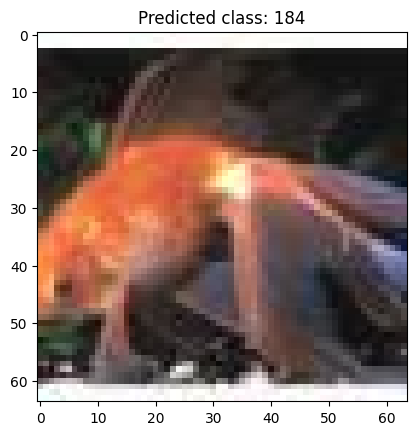

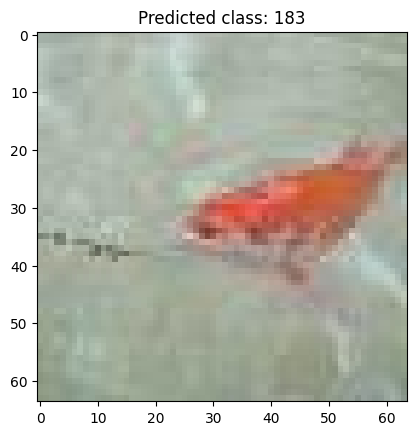

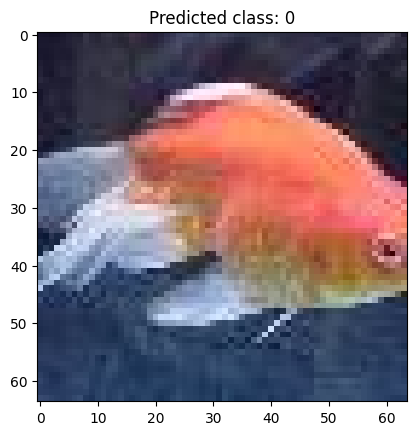

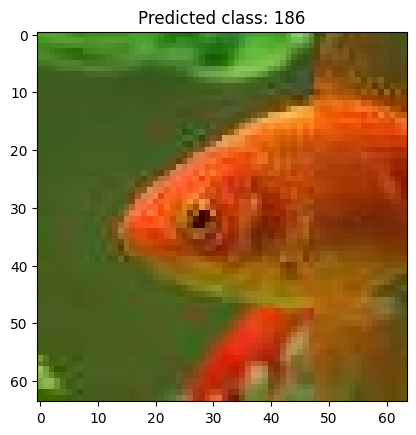

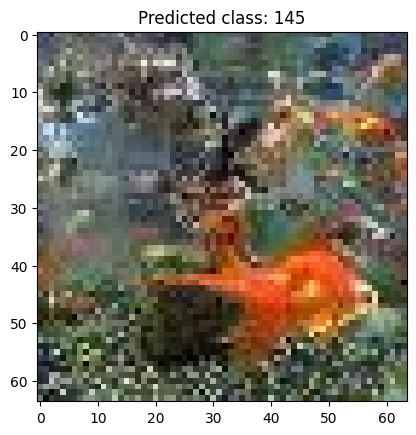

In [32]:
images,labels = next(iter(val_loader))

outputs = model(images.to(device))

_,pred = torch.max(outputs,1)

for i in range(5):

    plt.imshow(images[i].permute(1,2,0))
    plt.title("Predicted class: " + str(pred[i].item()))
    plt.show()